In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [3]:
forest_df = pd.read_csv(
    "../cleaned_data/forest_raw.csv"
)

grassland_df = pd.read_csv(
    "../cleaned_data/grassland_raw.csv"
)

print(forest_df.shape)
print(grassland_df.shape)

(8546, 30)
(8531, 30)


In [4]:
forest_only = set(forest_df.columns) - set(grassland_df.columns)

grassland_only = set(grassland_df.columns) - set(forest_df.columns)

print("Forest Only Columns")
print(forest_only)

print("\nGrassland Only Columns")
print(grassland_only)

Forest Only Columns
{'NPSTaxonCode', 'Site_Name'}

Grassland Only Columns
{'TaxonCode', 'Previously_Obs'}


In [5]:
grassland_df["Site_Name"] = "Grassland_Site"

In [6]:
grassland_df.rename(
    columns={
        "TaxonCode":"NPSTaxonCode"
    },
    inplace=True
)

In [7]:
grassland_df.columns.tolist()

['Admin_Unit_Code',
 'Sub_Unit_Code',
 'Plot_Name',
 'Location_Type',
 'Year',
 'Date',
 'Start_Time',
 'End_Time',
 'Observer',
 'Visit',
 'Interval_Length',
 'ID_Method',
 'Distance',
 'Flyover_Observed',
 'Sex',
 'Common_Name',
 'Scientific_Name',
 'AcceptedTSN',
 'NPSTaxonCode',
 'AOU_Code',
 'PIF_Watchlist_Status',
 'Regional_Stewardship_Status',
 'Temperature',
 'Humidity',
 'Sky',
 'Wind',
 'Disturbance',
 'Previously_Obs',
 'Initial_Three_Min_Cnt',
 'Admin_Sheet',
 'Site_Name']

In [8]:
grassland_df.drop(
    columns=["Previously_Obs"],
    inplace=True
)

In [9]:
forest_df["Habitat"] = "Forest"

In [10]:
grassland_df["Habitat"] = "Grassland"

In [11]:
common_columns = sorted(
    list(
        set(forest_df.columns)
        & set(grassland_df.columns)
    )
)

forest_df = forest_df[common_columns]
grassland_df = grassland_df[common_columns]

In [12]:
birds_df = pd.concat(
    [forest_df, grassland_df],
    ignore_index=True
)

In [13]:
print("Merged Shape")
print(birds_df.shape)

Merged Shape
(17077, 31)


In [14]:
birds_df["Habitat"].value_counts()

Habitat
Forest       8546
Grassland    8531
Name: count, dtype: int64

In [15]:
birds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   AOU_Code                     17077 non-null  str    
 1   AcceptedTSN                  17044 non-null  float64
 2   Admin_Sheet                  17077 non-null  str    
 3   Admin_Unit_Code              17077 non-null  str    
 4   Common_Name                  17077 non-null  str    
 5   Date                         17077 non-null  str    
 6   Distance                     15591 non-null  str    
 7   Disturbance                  17077 non-null  str    
 8   End_Time                     17077 non-null  str    
 9   Flyover_Observed             17077 non-null  bool   
 10  Habitat                      17077 non-null  str    
 11  Humidity                     17077 non-null  float64
 12  ID_Method                    17075 non-null  str    
 13  Initial_Three_Min_Cnt      

In [16]:
birds_df.to_csv(
    "../cleaned_data/birds_merged.csv",
    index=False
)

print("Merged dataset saved")

Merged dataset saved


In [17]:
birds_df.shape

(17077, 31)

In [18]:
birds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   AOU_Code                     17077 non-null  str    
 1   AcceptedTSN                  17044 non-null  float64
 2   Admin_Sheet                  17077 non-null  str    
 3   Admin_Unit_Code              17077 non-null  str    
 4   Common_Name                  17077 non-null  str    
 5   Date                         17077 non-null  str    
 6   Distance                     15591 non-null  str    
 7   Disturbance                  17077 non-null  str    
 8   End_Time                     17077 non-null  str    
 9   Flyover_Observed             17077 non-null  bool   
 10  Habitat                      17077 non-null  str    
 11  Humidity                     17077 non-null  float64
 12  ID_Method                    17075 non-null  str    
 13  Initial_Three_Min_Cnt      

In [20]:
missing_values = birds_df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Count": missing_values.values,
    "Missing_Percentage":
        np.round(
            (missing_values.values / len(birds_df)) * 100,
            2
        )
})

missing_df.sort_values(
    by="Missing_Count",
    ascending=False
)

,Column,Missing_Count,Missing_Percentage
26,Sub_Unit_Code,16355,95.77
22,Sex,5183,30.35
6,Distance,1486,8.70
1,AcceptedTSN,33,0.19
16,NPSTaxonCode,2,0.01
12,ID_Method,2,0.01
2,Admin_Sheet,0,0.00
5,Date,0,0.00
7,Disturbance,0,0.00
9,Flyover_Observed,0,0.00


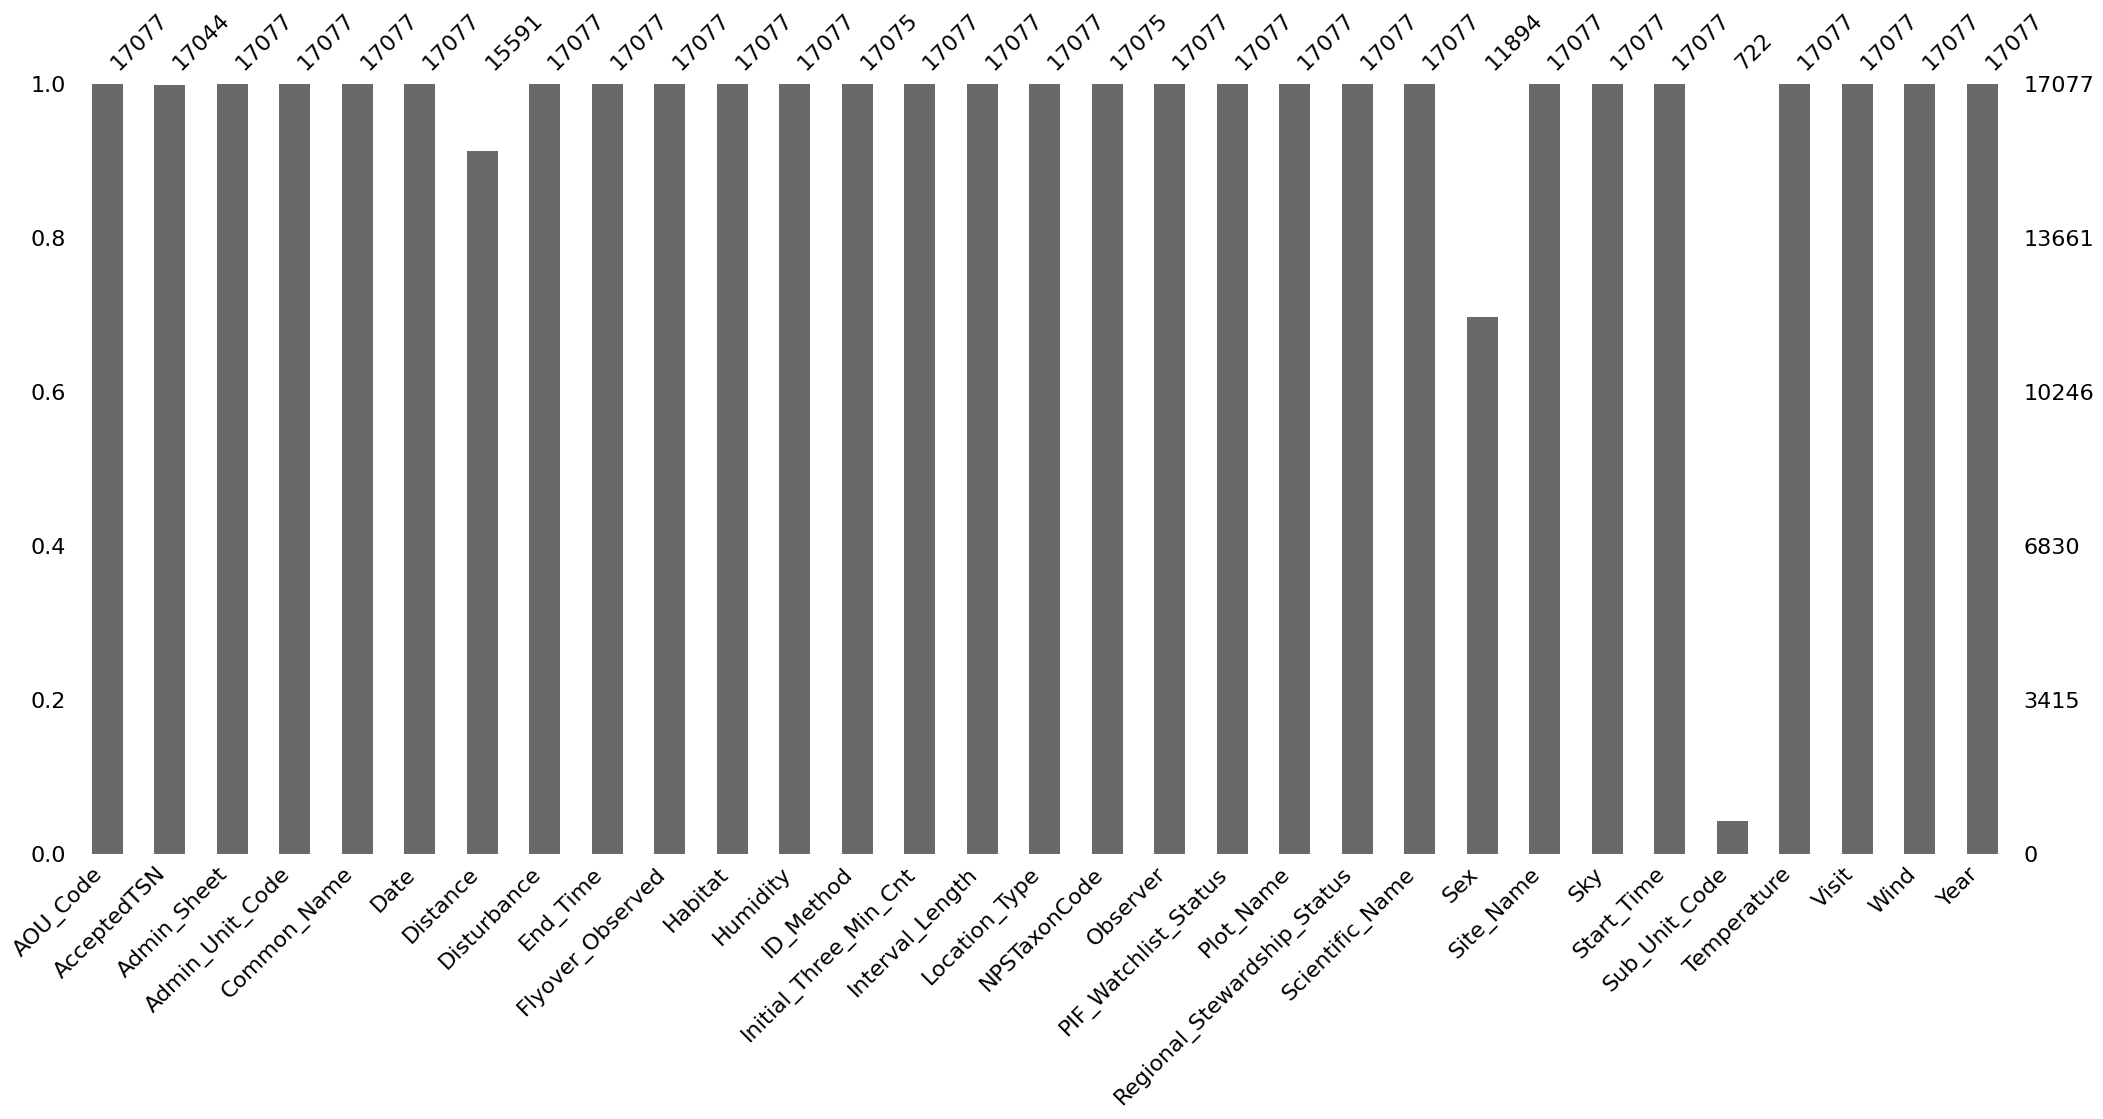

In [21]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
msno.bar(birds_df)

plt.show()

In [22]:
birds_df.drop(
    columns=["Sub_Unit_Code"],
    inplace=True
)

print(birds_df.shape)

(17077, 30)


In [23]:
birds_df["ID_Method"] = (
    birds_df["ID_Method"]
    .fillna("Unknown")
)

In [24]:
birds_df["ID_Method"].isnull().sum()

np.int64(0)

In [25]:
birds_df["NPSTaxonCode"] = (
    birds_df["NPSTaxonCode"]
    .fillna(-1)
)

In [26]:
birds_df["AcceptedTSN"] = (
    birds_df["AcceptedTSN"]
    .fillna(-1)
)

In [27]:
birds_df["Sex"].value_counts(dropna=False)

Sex
Undetermined    8410
NaN             5183
Male            3338
Female           146
Name: count, dtype: int64

In [28]:
birds_df["Sex"] = (
    birds_df["Sex"]
    .fillna("Unknown")
)

In [29]:
birds_df["Distance"].value_counts(dropna=False)

Distance
50 - 100 Meters    8239
<= 50 Meters       7352
NaN                1486
Name: count, dtype: int64

In [30]:
birds_df["Distance"] = (
    birds_df["Distance"]
    .fillna("Unknown")
)

In [31]:
birds_df.isnull().sum()

AOU_Code                       0
AcceptedTSN                    0
Admin_Sheet                    0
Admin_Unit_Code                0
Common_Name                    0
Date                           0
Distance                       0
Disturbance                    0
End_Time                       0
Flyover_Observed               0
Habitat                        0
Humidity                       0
ID_Method                      0
Initial_Three_Min_Cnt          0
Interval_Length                0
Location_Type                  0
NPSTaxonCode                   0
Observer                       0
PIF_Watchlist_Status           0
Plot_Name                      0
Regional_Stewardship_Status    0
Scientific_Name                0
Sex                            0
Site_Name                      0
Sky                            0
Start_Time                     0
Temperature                    0
Visit                          0
Wind                           0
Year                           0
dtype: int

In [32]:
birds_df.duplicated().sum()

np.int64(1705)

In [38]:
birds_df["Date"] = pd.to_datetime(
    birds_df["Date"],
    format="mixed"
)

In [40]:
birds_df["Date"].dtype

dtype('<M8[us]')

In [36]:
birds_df["Date"].head(20)

0     2018-05-22
1     2018-05-22
2     2018-05-22
3     2018-05-22
4     2018-05-22
5     2018-05-22
6     2018-05-22
7     2018-05-22
8     2018-05-22
9     2018-05-22
10    2018-05-22
11    2018-05-22
12    2018-05-22
13    2018-05-22
14    2018-05-22
15    2018-05-22
16    2018-05-22
17    2018-05-22
18    2018-05-22
19    2018-05-22
Name: Date, dtype: str

In [39]:
birds_df["Date"].dtype

dtype('<M8[us]')

In [41]:
birds_df["Month"] = birds_df["Date"].dt.month

birds_df["Month_Name"] = (
    birds_df["Date"]
    .dt.month_name()
)

birds_df["Quarter"] = (
    birds_df["Date"]
    .dt.quarter
)

In [42]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"

In [43]:
birds_df["Season"] = (
    birds_df["Month"]
    .apply(get_season)
)

In [44]:
birds_df["Season"].value_counts()

Season
Summer    11481
Spring     5596
Name: count, dtype: int64

In [45]:
birds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   AOU_Code                     17077 non-null  str           
 1   AcceptedTSN                  17077 non-null  float64       
 2   Admin_Sheet                  17077 non-null  str           
 3   Admin_Unit_Code              17077 non-null  str           
 4   Common_Name                  17077 non-null  str           
 5   Date                         17077 non-null  datetime64[us]
 6   Distance                     17077 non-null  str           
 7   Disturbance                  17077 non-null  str           
 8   End_Time                     17077 non-null  str           
 9   Flyover_Observed             17077 non-null  bool          
 10  Habitat                      17077 non-null  str           
 11  Humidity                     17077 non-null  float64

In [46]:
birds_df.to_csv(
    "../cleaned_data/birds_cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [47]:
birds_df[
    birds_df.duplicated()
].shape

(1705, 34)

In [48]:
birds_df[
    birds_df.duplicated()
].head(10)

,AOU_Code,AcceptedTSN,Admin_Sheet,Admin_Unit_Code,Common_Name,Date,Distance,Disturbance,End_Time,Flyover_Observed,Habitat,Humidity,ID_Method,Initial_Three_Min_Cnt,Interval_Length,Location_Type,NPSTaxonCode,Observer,PIF_Watchlist_Status,Plot_Name,Regional_Stewardship_Status,Scientific_Name,Sex,Site_Name,Sky,Start_Time,Temperature,Visit,Wind,Year,Month,Month_Name,Quarter,Season
8553,GRSP,179333.0,ANTI,ANTI,Grasshopper Sparrow,2018-05-22,<= 50 Meters,Slight effect on count,05:45:00,False,Grassland,79.000000,Singing,True,0-2.5 min,Grassland,83867.0,Elizabeth Oswald,False,ANTI-0054,False,Ammodramus savannarum,Male,Grassland_Site,Cloudy/Overcast,05:35:00,20.000000,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8572,MODO,177125.0,ANTI,ANTI,Mourning Dove,2018-05-22,50 - 100 Meters,Slight effect on count,07:06:00,False,Grassland,80.300003,Singing,True,0-2.5 min,Grassland,82737.0,Elizabeth Oswald,False,ANTI-0028,False,Zenaida macroura,Undetermined,Grassland_Site,Cloudy/Overcast,06:56:00,19.799999,1,Light air movement (1-3 mph) smoke drifts,2018,5,May,2,Spring
8586,CANG,174999.0,ANTI,ANTI,Canada Goose,2018-05-22,Unknown,No effect on count,06:49:00,True,Grassland,79.500000,Visualization,False,2.5 - 5 min,Grassland,76625.0,Elizabeth Oswald,False,ANTI-0027,False,Branta canadensis,Undetermined,Grassland_Site,Cloudy/Overcast,06:39:00,20.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8594,FISP,179443.0,ANTI,ANTI,Field Sparrow,2018-05-22,50 - 100 Meters,No effect on count,06:49:00,False,Grassland,79.500000,Singing,True,0-2.5 min,Grassland,84790.0,Elizabeth Oswald,False,ANTI-0027,True,Spizella pusilla,Male,Grassland_Site,Cloudy/Overcast,06:39:00,20.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8598,EATO,179276.0,ANTI,ANTI,Eastern Towhee,2018-05-22,50 - 100 Meters,No effect on count,06:49:00,False,Grassland,79.500000,Calling,True,0-2.5 min,Grassland,83803.0,Elizabeth Oswald,False,ANTI-0027,True,Pipilo erythrophthalmus,Undetermined,Grassland_Site,Cloudy/Overcast,06:39:00,20.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8605,NOCA,179124.0,ANTI,ANTI,Northern Cardinal,2018-05-22,50 - 100 Meters,Slight effect on count,07:39:00,False,Grassland,84.400002,Singing,True,0-2.5 min,Grassland,94228.0,Elizabeth Oswald,False,ANTI-0018,False,Cardinalis cardinalis,Undetermined,Grassland_Site,Cloudy/Overcast,07:29:00,20.200001,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
8617,CEDW,178532.0,ANTI,ANTI,Cedar Waxwing,2018-05-22,Unknown,No effect on count,06:53:00,True,Grassland,72.300003,Visualization,False,5 - 7.5 min,Grassland,88296.0,Kimberly Serno,False,ANTI-0105,False,Bombycilla cedrorum,Undetermined,Grassland_Site,Cloudy/Overcast,06:43:00,21.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8624,FISP,179443.0,ANTI,ANTI,Field Sparrow,2018-05-22,<= 50 Meters,No effect on count,06:53:00,False,Grassland,72.300003,Singing,True,0-2.5 min,Grassland,84790.0,Kimberly Serno,False,ANTI-0105,True,Spizella pusilla,Male,Grassland_Site,Cloudy/Overcast,06:43:00,21.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8631,FISP,179443.0,ANTI,ANTI,Field Sparrow,2018-05-22,50 - 100 Meters,No effect on count,06:53:00,False,Grassland,72.300003,Singing,True,0-2.5 min,Grassland,84790.0,Kimberly Serno,False,ANTI-0105,True,Spizella pusilla,Male,Grassland_Site,Cloudy/Overcast,06:43:00,21.200001,1,Light breeze (4-7 mph) wind felt on face,2018,5,May,2,Spring
8647,FISP,179443.0,ANTI,ANTI,Field Sparrow,2018-05-22,50 - 100 Meters,No effect on count,07:12:00,False,Grassland,74.199997,Singing,True,0-2.5 min,Grassland,84790.0,Kimberly Serno,False,ANTI-0090,True,Spizella pusilla,Male,Grassland_Site,Cloudy/Overcast,07:02:00,21.400000,1,Light air movement (1-3 mph) smoke drifts,2018,5,May,2,Spring


In [49]:
birds_df[
    birds_df.duplicated()
].shape

(1705, 34)

In [50]:
birds_df["Season"].value_counts()

Season
Summer    11481
Spring     5596
Name: count, dtype: int64

In [51]:
duplicate_percentage = (
    birds_df.duplicated().sum()
    / len(birds_df)
) * 100

print(f"{duplicate_percentage:.2f}%")

9.98%


In [52]:
birds_df = birds_df.drop_duplicates()

print(birds_df.shape)

(15372, 34)


In [53]:
birds_df.duplicated().sum()

np.int64(0)

In [54]:
birds_df.to_csv(
    "../cleaned_data/birds_cleaned.csv",
    index=False
)

print("Final Clean Dataset Saved")

Final Clean Dataset Saved
